# Backpropagation

<img src="img/title.png" width="600">

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Latex

<br><br><br>

## Why we need derivatives

We want to minimize a loss function in terms of some model parameters $\ell(p_1, p_2, \ldots, p_{N_p})$.

In general, we'll need a non-linear optimization algorithm.

Some optimization algorithms work with just the function:
* Nelder-Mead simplex
* Powell's method
* Simulated annealing (inspired by cooling metal)
* Genetic algorithms (inspired by biological evolution)
* ...

But algorithms that are given the derivative,

$$ \nabla \ell = \left( \frac{d\ell}{dp_1}, \frac{d\ell}{dp_2}, \ldots, \frac{d\ell}{dp_{N_p}} \right) $$

need to evaluate fewer points $(p_1, p_2, \ldots, p_{N_p})$ to determine the shape of the surface and therefore find the minimum faster.

* Gradient descent
* BFGS, L-BFGS-B
* Adam
* Stochastic gradient descent
* ...

<br><br><br>

<img src="img/downhill.png" width="600">

<br><br><br>

## How computers compute derivatives

* **Symbolic:** like doing calculus by hand
* **Finite differences:** numerical with a "small enough" step size $\Delta p_i$
* **Autodiff:** by propagating each operation using the chain rule

<br><br><br>

## Example of something to differentiate

<img src="img/example.png" width="600">

Activation function:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

First layer:

$$ \begin{aligned}
z_1 &= p_1 \, x_1 + p_4 \, x_2 + p_7 \\
z_2 &= p_2 \, x_1 + p_5 \, x_2 + p_8 \\
z_3 &= p_3 \, x_1 + p_6 \, x_2 + p_9 \\
\end{aligned} $$

Second layer:

$$ \hat{y} = p_{10} \, \sigma(z_1) + p_{11} \, \sigma(z_2) + p_{12} \, \sigma(z_3) + p_{13} $$

Loss is predicted minus target squared:

$$ \ell(p_1, p_2, \ldots p_{13}) = \left( \hat{y} - y \right)^2 $$

<br><br><br>

## Symbolic differentiation

In [2]:
# Symbols
x1, x2, y = sp.symbols("x1 x2 y")
(p1, p2, p3, p4, p5, p6, p7, p8, p9,
 p10, p11, p12, p13) = params = sp.symbols("p1:14")

# Activation function
def sigma(z):
    return 1 / (1 + sp.exp(-z))

# First layer
z1 = p1*x1 + p4*x2 + p7
z2 = p2*x1 + p5*x2 + p8
z3 = p3*x1 + p6*x2 + p9

# Second layer
yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

# Loss
ell = (yhat - y)**2

# Derivatives d ell / d p_i
derivatives = {
    p_i: sp.simplify(sp.diff(ell, p_i))
    for p_i in params
}

In [22]:
# Print results
for i, deriv in enumerate(derivatives.values()):
    display(Latex(f"$$ \\frac{{d\\ell}}{{dp_{{{i}}}}} = {sp.latex(deriv)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<br><br><br>

In [4]:
import random

values = {
    x1: random.uniform(-1, 1),
    x2: random.uniform(-1, 1),
    y: random.uniform(-1, 1),
}
for p_i in params:
    values[p_i] = random.uniform(-1, 1)

print(f"ℓ = {ell.subs(values).evalf():.2f}\n")

for p_i, deriv in derivatives.items():
    print(f"dℓ / d{p_i} = {deriv.subs(values).evalf():.2f}")

ℓ = 0.29

dℓ / dp1 = 0.01
dℓ / dp2 = -0.02
dℓ / dp3 = 0.02
dℓ / dp4 = 0.01
dℓ / dp5 = -0.01
dℓ / dp6 = 0.01
dℓ / dp7 = 0.06
dℓ / dp8 = -0.12
dℓ / dp9 = 0.18
dℓ / dp10 = 0.72
dℓ / dp11 = 0.66
dℓ / dp12 = 0.33
dℓ / dp13 = 1.08

<br><br><br>

This does not scale well to a large number of parameters.

<br><br><br>

## Finite differences

<img src="img/finite-differences.png" width="600">

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i)}{\Delta p_i} $$

Or with more precision:

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i - \Delta p_i)}{2 \Delta p_i} $$

(The error is quadratic in $\Delta p_i$.)

In [5]:
# Redefine as ordinary numbers, not SymPy

values = {str(k): v for k, v in values.items()}

x1 = values["x1"]
x2 = values["x2"]
y = values["y"]

params = [values[f"p{i+1}"] for i in range(13)]

def sigma(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def calculate_ell(params):
    (p1, p2, p3, p4, p5, p6, p7, p8, p9,
     p10, p11, p12, p13) = params

    # First layer
    z1 = p1*x1 + p4*x2 + p7
    z2 = p2*x1 + p5*x2 + p8
    z3 = p3*x1 + p6*x2 + p9
    
    # Second layer
    yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13
    
    # Loss
    ell = (yhat - y)**2
    return ell


def derivative_of_ell(params, which):
    low_params = list(params)
    high_params = list(params)

    low_params[which] -= deltapi
    high_params[which] += deltapi

    return (calculate_ell(high_params) - calculate_ell(low_params)) / (2*deltapi)

In [7]:
deltapi = 0.001

print(f"ℓ = {calculate_ell(params):.2f}\n")

for i in range(13):
    print(f"dℓ / dp{i+1} = {derivative_of_ell(params, i):.2f}")

ℓ = 0.29

dℓ / dp1 = 0.01
dℓ / dp2 = -0.02
dℓ / dp3 = 0.02
dℓ / dp4 = 0.01
dℓ / dp5 = -0.01
dℓ / dp6 = 0.01
dℓ / dp7 = 0.06
dℓ / dp8 = -0.12
dℓ / dp9 = 0.18
dℓ / dp10 = 0.72
dℓ / dp11 = 0.66
dℓ / dp12 = 0.33
dℓ / dp13 = 1.08

<br><br><br>

How small should $\Delta p_i$ be?
* Smaller than any of the function's "wiggles"
* Not so small as to encourage round-off error

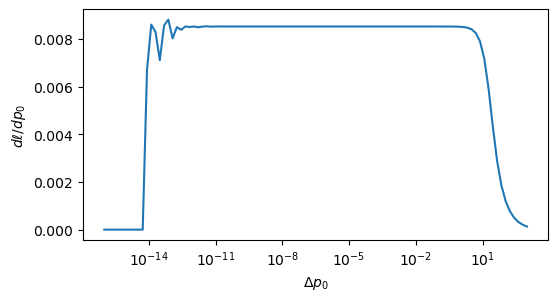

In [38]:
fig, ax = plt.subplots(figsize=(6, 3))

deltapis = 10**np.linspace(-16, 3, 100)

dell_dp0s = []
for deltapi in deltapis:
    dell_dp0s.append(derivative_of_ell(params, 0))

ax.plot(deltapis, dell_dp0s)
ax.set_xscale("log")
ax.set_xlabel("$\\Delta p_0$")
ax.set_ylabel("$d\\ell / dp_0$")

None

<br><br><br>

## Autodiff